<a href="https://colab.research.google.com/github/anhxul/Brain_tumor_detection/blob/main/Brain_tumor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import kagglehub

path = kagglehub.dataset_download("navoneel/brain-mri-images-for-brain-tumor-detection")
print("Dataset path:", path)

100%|██████████| 15.1M/15.1M [00:00<00:00, 16.6MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/versions/1


In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [4]:
img_size = 128

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_size, img_size),
    batch_size=32
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_size, img_size),
    batch_size=32
)

class_names = train_data.class_names
print(class_names)

Found 506 files belonging to 3 classes.
Using 405 files for training.
Found 506 files belonging to 3 classes.
Using 101 files for validation.
['brain_tumor_dataset', 'no', 'yes']


In [5]:
model = tf.keras.Sequential([
    layers.Input(shape=(128,128,3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu', name="last_conv"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])


In [6]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=12   # 🔥 increase epochs
)

Epoch 1/12
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 453ms/step - accuracy: 0.2000 - loss: 0.6752 - val_accuracy: 0.2079 - val_loss: 0.4744
Epoch 2/12
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.1901 - loss: 0.5270 - val_accuracy: 0.2079 - val_loss: 0.4317
Epoch 3/12
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.1901 - loss: 0.5316 - val_accuracy: 0.2079 - val_loss: 0.4342
Epoch 4/12
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.1901 - loss: 0.4768 - val_accuracy: 0.2079 - val_loss: 0.4180
Epoch 5/12
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.1975 - loss: 0.5892 - val_accuracy: 0.2079 - val_loss: 0.4870
Epoch 6/12
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.1901 - loss: 0.5049 - val_accuracy: 0.2079 - val_loss: 0.4324
Epoch 7/12
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.1852 - loss: 0.4883 - val_accuracy: 0.1980 - val_loss: 0.4375
Epoch 8/12
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.1951 - loss: 0.5035 - val_accuracy: 0.1881 -

In [7]:
def predict_image(img_path):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(128,128))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)[0][0]

    print("Raw prediction:", pred)

    if pred > 0.4:   # 🔥 threshold adjust
        print("Tumor Detected ❌")
    else:
        print("No Tumor ✅")

    return img_array

In [8]:
def get_cam(model, img_array):
    last_conv_layer = model.get_layer("last_conv")

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)

    return heatmap   # ✅ FIXED

In [9]:
def show_cam(img_path):
    img_array = predict_image(img_path)

    heatmap = get_cam(model, img_array)

    img = cv2.imread(img_path)
    img = cv2.resize(img, (128,128))

    heatmap = cv2.resize(heatmap, (128,128))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = heatmap * 0.4 + img

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.title("Original")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    plt.subplot(1,2,2)
    plt.title("CAM")
    plt.imshow(cv2.cvtColor(superimposed_img.astype('uint8'), cv2.COLOR_BGR2RGB))

    plt.show()

In [10]:
from tensorflow.keras import layers, Model, Input

inputs = Input(shape=(128,128,3))

x = layers.Rescaling(1./255)(inputs)

x = layers.Conv2D(16, 3, activation='relu')(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(32, 3, activation='relu')(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(64, 3, activation='relu', name="last_conv")(x)  # 🔥 important
x = layers.MaxPooling2D()(x)

x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,629,473 (6.22 MB)

 Trainable params: 1,629,473 (6.22 MB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
Raw prediction: 0.48644212
Tumor Detected ❌


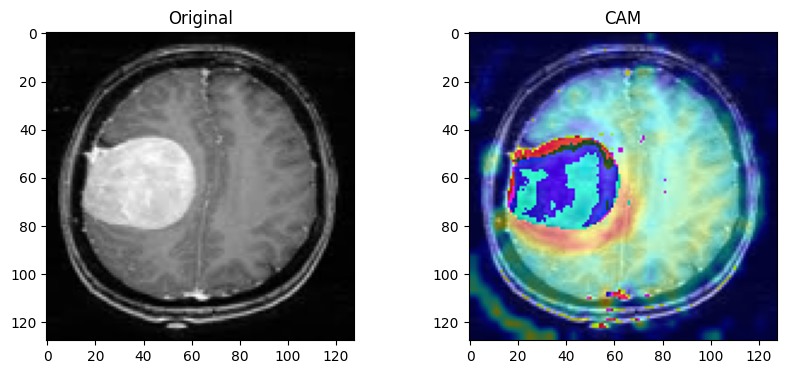

In [13]:
test_img = path + "/yes/Y1.jpg"
show_cam(test_img)